<a href="https://colab.research.google.com/github/ssathwick007-creator/FOML_192525127_S-Sathwick/blob/main/192525127_S_Sathwick_FOML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a given set of training data samples.

In [ ]:
import pandas as pd
import numpy as np

# Sample dataset (EnjoySport concept learning dataset)
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)
print("--- Training Dataset ---")
print(df)
print("\n" + "="*50 + "\n")

# Separate attributes (X) and target concept (y)
attributes = np.array(df.iloc[:, :-1])
target = np.array(df.iloc[:, -1])

def train_find_s(concepts, target):
    """
    Implements the FIND-S Algorithm to find the most specific hypothesis.
    """
    # 1. Initialize hypothesis with the first positive training instance
    specific_h = None
    for i, val in enumerate(target):
        if val == 'Yes':
            specific_h = concepts[i].copy()
            break

    if specific_h is None:
        raise ValueError("No positive examples found in the training data.")

    print(f"Initial Hypothesis: {specific_h}\n")

    # 2. Iterate through each instance in the training set
    for i, val in enumerate(concepts):
        if target[i] == 'Yes':
            for x in range(len(specific_h)):
                # If the attribute value differs, generalize with '?'
                if val[x] != specific_h[x]:
                    specific_h[x] = '?'
            print(f"Instance {i + 1} (Positive) -> Current Hypothesis: {specific_h}")
        else:
            print(f"Instance {i + 1} (Negative) -> Ignored")

    return specific_h

# Execute FIND-S
final_hypothesis = train_find_s(attributes, target)

print("\n" + "="*50)
print(f"Final Most Specific Hypothesis: {final_hypothesis}")

--- Training Dataset ---
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes


Initial Hypothesis: ['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']

Instance 1 (Positive) -> Current Hypothesis: ['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']
Instance 2 (Positive) -> Current Hypothesis: ['Sunny' 'Warm' '?' 'Strong' 'Warm' 'Same']
Instance 3 (Negative) -> Ignored
Instance 4 (Positive) -> Current Hypothesis: ['Sunny' 'Warm' '?' 'Strong' '?' '?']

Final Most Specific Hypothesis: ['Sunny' 'Warm' '?' 'Strong' '?' '?']


2. For a given set of training data examples stored in a .CSV file, implement and demonstrate the Candidate-Elimination algorithm in python to output a description of the set of all hypotheses consistent with the training examples

In [ ]:
import pandas as pd

# Training dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Weak'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("Training Data:")
print(df)

attributes = list(df.columns[:-1])

# Initialize Specific and General hypotheses
S = ['0'] * len(attributes)
G = [['?'] * len(attributes)]

for _, row in df.iterrows():

    example = list(row[:-1])
    target = row['EnjoySport']

    if target == 'Yes':
        # Remove inconsistent general hypotheses
        G = [g for g in G if all(g[i] == '?' or g[i] == example[i]
                                 for i in range(len(attributes)))]

        # Generalize S
        for i in range(len(attributes)):
            if S[i] == '0':
                S[i] = example[i]
            elif S[i] != example[i]:
                S[i] = '?'

    else:
        # Specialize G
        new_G = []

        for g in G:
            for i in range(len(attributes)):
                if g[i] == '?':
                    if S[i] != '?' and S[i] != '0':
                        new_h = g.copy()
                        new_h[i] = S[i]
                        new_G.append(new_h)

        G = new_G

print("\nSpecific Hypothesis (S):")
print(S)

print("\nGeneral Hypotheses (G):")
for g in G:
    print(g)

Training Data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High    Weak  Cool   Change        Yes

Specific Hypothesis (S):
['Sunny', 'Warm', '?', '?', '?', '?']

General Hypotheses (G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']


3.Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.

Decision Tree created successfully.


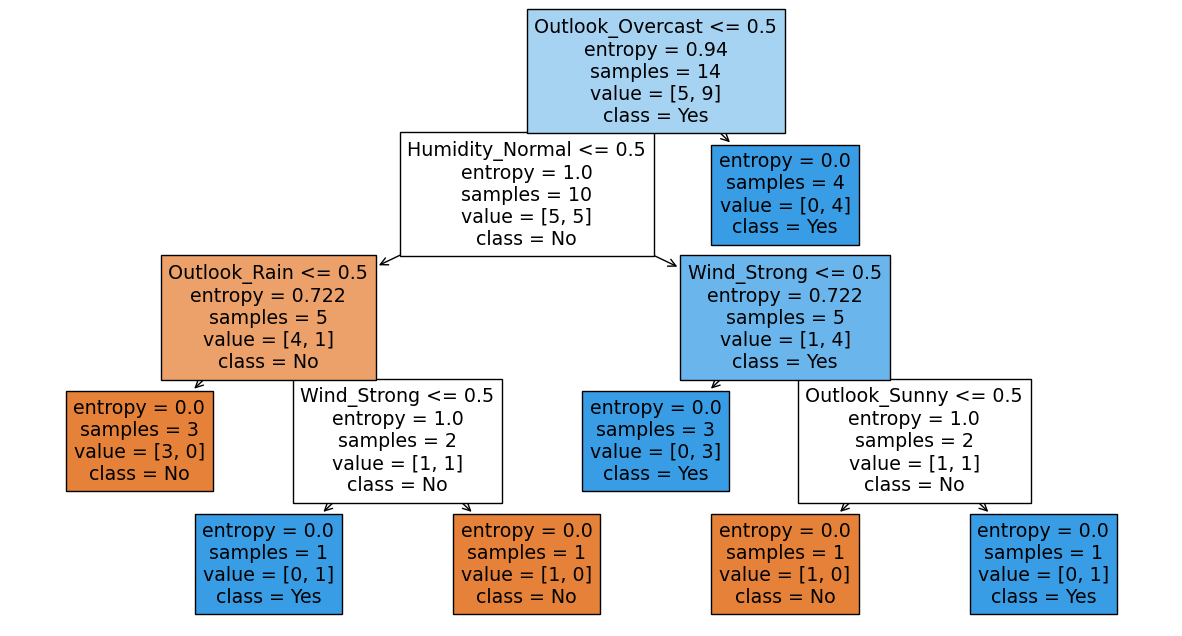

Prediction: No


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                'Overcast','Sunny','Sunny','Rain','Sunny','Overcast',
                'Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool',
                    'Cool','Mild','Cool','Mild','Mild','Mild',
                    'Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal',
                 'Normal','High','Normal','Normal','Normal','High',
                 'Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong',
             'Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes',
             'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Convert categorical values into numbers
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play']

# Create ID3 Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

print("Decision Tree created successfully.")

# Display tree
plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=X.columns,
          class_names=model.classes_,
          filled=True)
plt.show()

# Predict a new sample
new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_sample)

print("Prediction:", prediction[0])

4.Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the same using appropriate data sets.

In [ ]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Create ANN
model = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

# Train the model
model.fit(X, y)

# Prediction
predictions = model.predict(X)

print("Actual Output:")
print(y)

print("\nPredicted Output:")
print(predictions)

print("\nAccuracy:",
      accuracy_score(y, predictions) * 100, "%")

Actual Output:
[0 1 1 0]

Predicted Output:
[0 1 0 1]

Accuracy: 50.0 %


5.Write a program for Implementation of K-Nearest Neighbours (K-NN) in Python

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("K-NN Classification")
print("-------------------")
print("Number of Test Samples:", len(X_test))
print("Accuracy:", accuracy * 100, "%")

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

K-NN Classification
-------------------
Number of Test Samples: 30
Accuracy: 100.0 %
Predicted Flower: setosa


6. Write a program to implement Naïve Bayes algorithm in python and to display the results  using confusion matrix and accuracy.

Naive Bayes Classification
Accuracy: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


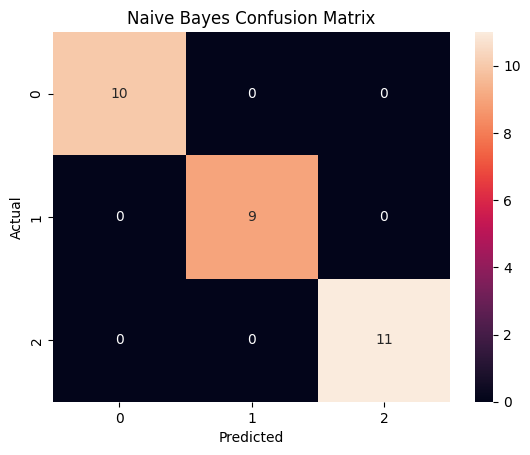

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Classification")
print("Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

7.Write a program to implement Logistic Regression (LR) algorithm in python

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy:", accuracy * 100, "%")

# New sample prediction
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Class:", prediction[0])

Logistic Regression
-------------------
Accuracy: 100.0 %
Predicted Class: 0


8.Write a program to implement Linear Regression (LR) algorithm in python

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
X = np.array([[1], [2], [3], [4], [5],
              [6], [7], [8], [9], [10]])

y = np.array([2, 4, 6, 8, 10,
              12, 14, 16, 18, 20])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Linear Regression")
print("-----------------")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nActual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

print("\nMean Squared Error:",
      mean_squared_error(y_test, y_pred))

print("R2 Score:",
      r2_score(y_test, y_pred))

# Predict new value
new_value = [[11]]
print("\nPrediction for 11:",
      model.predict(new_value)[0])

Linear Regression
-----------------
Slope: 2.0000000000000004
Intercept: -1.7763568394002505e-15

Actual Values:
[18  4]

Predicted Values:
[18.  4.]

Mean Squared Error: 3.944304526105059e-31
R2 Score: 1.0

Prediction for 11: 22.0


9 Compare  Linear and Polynomial Regression using Python

Linear Regression MSE: 52.79999999999997
Polynomial Regression MSE: 2.3922206950827182e-29


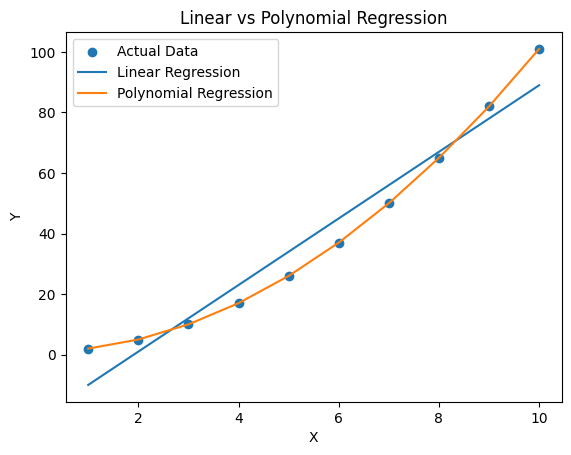

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Dataset
X = np.array([[1], [2], [3], [4], [5],
              [6], [7], [8], [9], [10]])

y = np.array([2, 5, 10, 17, 26,
              37, 50, 65, 82, 101])

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)

linear_pred = linear_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

poly_pred = poly_model.predict(X_poly)

# Print results
print("Linear Regression MSE:",
      mean_squared_error(y, linear_pred))

print("Polynomial Regression MSE:",
      mean_squared_error(y, poly_pred))

# Plot
plt.scatter(X, y, label="Actual Data")
plt.plot(X, linear_pred, label="Linear Regression")
plt.plot(X, poly_pred, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

10 Write a Python Program to Implement Expectation & Maximization Algorithm

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture

# Dataset
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [8, 8],
    [8, 9],
    [9, 8],
    [9, 9]
])

# Create Gaussian Mixture Model
model = GaussianMixture(
    n_components=2,
    random_state=42
)

# Apply EM algorithm
model.fit(X)

# Predict clusters
labels = model.predict(X)

print("Expectation-Maximization Algorithm")
print("-----------------------------------")

print("\nData:")
print(X)

print("\nCluster Labels:")
print(labels)

print("\nCluster Means:")
print(model.means_)

print("\nCluster Probabilities:")
print(model.predict_proba(X))

Expectation-Maximization Algorithm
-----------------------------------

Data:
[[1 1]
 [1 2]
 [2 1]
 [2 2]
 [8 8]
 [8 9]
 [9 8]
 [9 9]]

Cluster Labels:
[0 0 0 0 1 1 1 1]

Cluster Means:
[[1.5 1.5]
 [8.5 8.5]]

Cluster Probabilities:
[[1.00000000e+00 5.22907872e-98]
 [1.00000000e+00 7.56174508e-86]
 [1.00000000e+00 7.56174508e-86]
 [1.00000000e+00 1.09350025e-73]
 [1.09350025e-73 1.00000000e+00]
 [7.56174508e-86 1.00000000e+00]
 [7.56174508e-86 1.00000000e+00]
 [5.22907872e-98 1.00000000e+00]]


11 Write a program for the task of Credit Score Classification

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'Income': [25000, 40000, 60000, 30000, 80000, 50000, 70000, 20000, 90000, 45000],
    'Loan': [10000, 15000, 20000, 12000, 25000, 18000, 22000, 8000, 30000, 16000],
    'CreditScore': ['Low', 'Low', 'High', 'Low', 'High',
                    'High', 'High', 'Low', 'High', 'High']
}

df = pd.DataFrame(data)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['CreditScore'])

X = df[['Income', 'Loan']]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Credit Score Classification")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New customer
new_customer = [[55000, 17000]]
prediction = model.predict(new_customer)

print("Predicted Credit Score:",
      le.inverse_transform(prediction)[0])

Credit Score Classification
Accuracy: 50.0 %
Predicted Credit Score: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


12 Implement Iris Flower Classification using KNN

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Iris Flower Classification using KNN")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

Iris Flower Classification using KNN
Accuracy: 100.0 %
Predicted Flower: setosa


13 Implement the Car Price Prediction Model using Python

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = {
    'Age': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Kilometers': [10000, 20000, 30000, 40000, 50000,
                   60000, 70000, 80000, 90000, 100000],
    'Price': [900000, 820000, 750000, 680000, 600000,
              530000, 460000, 400000, 330000, 280000]
}

df = pd.DataFrame(data)

X = df[['Age', 'Kilometers']]
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Car Price Prediction")
print("--------------------")
print("Actual Prices:", list(y_test))
print("Predicted Prices:", list(y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# New car prediction
new_car = [[3, 30000]]

print("Predicted Price:",
      model.predict(new_car)[0])

Car Price Prediction
--------------------
Actual Prices: [330000, 820000]
Predicted Prices: [np.float64(331810.3448275863), np.float64(818189.6551724139)]
MSE: 3277348.394768119
R2 Score: 0.9999454002766386
Predicted Price: 748706.8965517242


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


14 Implement House price Prediction using appropriate machine learning algorithm

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Dataset
data = {
    'Area': [800, 1000, 1200, 1400, 1600,
             1800, 2000, 2200, 2400, 2600],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Price': [2000000, 2500000, 3000000, 3500000, 4000000,
              4500000, 5000000, 5500000, 6000000, 6500000]
}

df = pd.DataFrame(data)

X = df[['Area', 'Bedrooms']]
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("House Price Prediction")
print("---------------------")
print("Actual Prices:", list(y_test))
print("Predicted Prices:", list(y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

# New house
new_house = [[1500, 3]]

print("Predicted House Price:",
      model.predict(new_house)[0])

House Price Prediction
---------------------
Actual Prices: [6000000, 2500000]
Predicted Prices: [np.float64(6000000.0), np.float64(2499999.9999999995)]
R2 Score: 1.0
Predicted House Price: 3749999.9999999995


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


 15 Implement Iris Flower Classification using Naive Bayes classifier

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
model = GaussianNB()

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Iris Classification using Naive Bayes")
print("--------------------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])

Iris Classification using Naive Bayes
--------------------------------------
Accuracy: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Predicted Flower: setosa


16 Compare different types Classification Algorithms and evaluate their performance.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200)
}

print("Classification Algorithm Comparison")
print("------------------------------------")

# Train and evaluate
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name, ":", accuracy * 100, "%")

Classification Algorithm Comparison
------------------------------------
KNN : 100.0 %
Decision Tree : 100.0 %
Naive Bayes : 100.0 %
Logistic Regression : 100.0 %


17 Implement Mobile Price Prediction using appropriate machine learning algorithm  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'RAM': [2, 3, 4, 6, 8, 2, 4, 6, 8, 12],
    'Storage': [32, 64, 64, 128, 256, 32, 128, 256, 512, 512],
    'Battery': [3000, 3500, 4000, 4500, 5000,
                3000, 4500, 5000, 5000, 6000],
    'Price_Range': ['Low', 'Low', 'Medium', 'Medium', 'High',
                    'Low', 'Medium', 'High', 'High', 'High']
}

df = pd.DataFrame(data)

X = df[['RAM', 'Storage', 'Battery']]
y = df['Price_Range']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Mobile Price Prediction")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New mobile
new_mobile = [[6, 128, 4500]]
prediction = model.predict(new_mobile)

print("Predicted Price Range:", prediction[0])

Mobile Price Prediction
Accuracy: 100.0 %
Predicted Price Range: Medium


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


18 Implement Perceptron based IRIS classification

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Perceptron model
model = Perceptron(max_iter=1000, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Perceptron Based IRIS Classification")
print("------------------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

Perceptron Based IRIS Classification
------------------------------------
Accuracy: 63.33333333333333 %
Predicted Flower: setosa


 19 Implementation of Naive Bayes classification for Bank Loan prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    'Age': [25, 35, 45, 28, 50, 40, 30, 55, 32, 48],
    'Income': [25000, 45000, 70000, 30000, 80000,
               60000, 35000, 90000, 40000, 75000],
    'LoanAmount': [10000, 20000, 30000, 12000, 40000,
                   25000, 15000, 50000, 18000, 35000],
    'Loan_Status': ['No', 'Yes', 'Yes', 'No', 'Yes',
                    'Yes', 'No', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Encode target
encoder = LabelEncoder()
y = encoder.fit_transform(df['Loan_Status'])

X = df[['Age', 'Income', 'LoanAmount']]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Bank Loan Prediction")
print("--------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# New customer
new_customer = [[35, 50000, 20000]]

prediction = model.predict(new_customer)

print("\nLoan Prediction:",
      encoder.inverse_transform(prediction)[0])

Bank Loan Prediction
--------------------
Accuracy: 100.0 %

Confusion Matrix:
[[1 0]
 [0 1]]

Loan Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


20 Implement Future Sales Prediction using a suitable machine learning algorithm

Future Sales Prediction
-----------------------
Month 11 Predicted Sales: 300.0
Month 12 Predicted Sales: 320.0
Month 13 Predicted Sales: 340.0
Month 14 Predicted Sales: 360.0
Month 15 Predicted Sales: 380.0


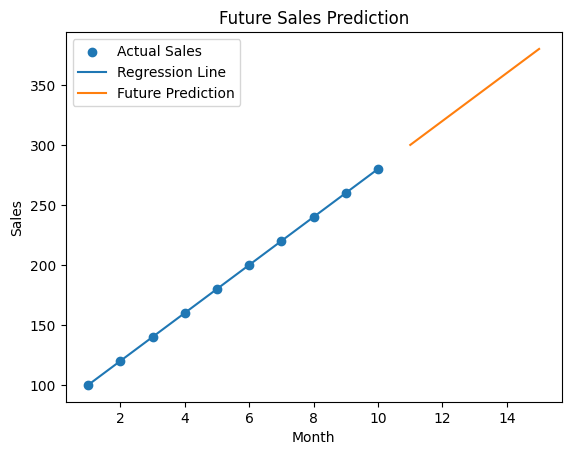

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sales data
months = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]).reshape(-1, 1)

sales = np.array([
    100, 120, 140, 160, 180,
    200, 220, 240, 260, 280
])

# Create model
model = LinearRegression()

# Train model
model.fit(months, sales)

# Predict future sales
future_months = np.array([
    11, 12, 13, 14, 15
]).reshape(-1, 1)

future_sales = model.predict(future_months)

print("Future Sales Prediction")
print("-----------------------")

for month, sale in zip(future_months.flatten(), future_sales):
    print("Month", month, "Predicted Sales:", round(sale, 2))

# Plot
plt.scatter(months, sales, label="Actual Sales")
plt.plot(months, model.predict(months), label="Regression Line")
plt.plot(future_months, future_sales, label="Future Prediction")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.legend()
plt.show()